In [ ]:
# --- Import libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# --- Load your uploaded file automatically ---
from google.colab import files
uploaded = files.upload()   # Upload "results analysis.csv"

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Automatically detect whatever file name Colab saves
file_name = list(uploaded.keys())[0]
print(f"Loaded file: {file_name}")

# Read the detected file
df = pd.read_csv(file_name)
df.columns = [c.strip() for c in df.columns]  # Clean headers
print(df.head())  # Optional: check first few rows



Saving results analysis - validation.csv to results analysis - validation.csv
Loaded file: results analysis - validation.csv
  Trials (n) Binding Affinity  Cavity Volume/Angstroms cubed
0      IRAK1         KIC-0101                            NaN
1          1             -9.9                         2099.0
2          2             -6.7                         2461.0
3          3             -6.8                         2461.0
4       RMSD       1.48548533                            NaN


In [ ]:
print(df.head(40))  # Optional: check first few rows


   Trials (n)   Binding Affinity  Cavity Volume/Angstroms cubed
0       IRAK1           KIC-0101                            NaN
1           1               -9.9                         2099.0
2           2               -6.7                         2461.0
3           3               -6.8                         2461.0
4        RMSD         1.48548533                            NaN
5       IRAK1        Phillygenin                            NaN
6           1               -8.7                         2461.0
7           2               -8.8                         2461.0
8           3               -8.7                         2461.0
9        RMSD      0.04714045208                            NaN
10      IRAK1      Icariiside ll                            NaN
11          1              -11.4                         2099.0
12          2              -10.8                         1449.0
13          3              -10.8                         2099.0
14       RMSD       0.2828427125        

In [ ]:
# --- Box Plot: Distribution of binding affinities per ligand ---
plt.figure(figsize=(8,6))
sns.boxplot(x='Ligand', y='Binding Affinity', data=df, palette='colorblind',medianprops=dict(linewidth=1.2),)
plt.title('Distribution of Binding Affinities per Ligand')
plt.ylabel('Binding Affinity (kcal/mol)')
plt.xlabel('Ligand')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=1)
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Ligand` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

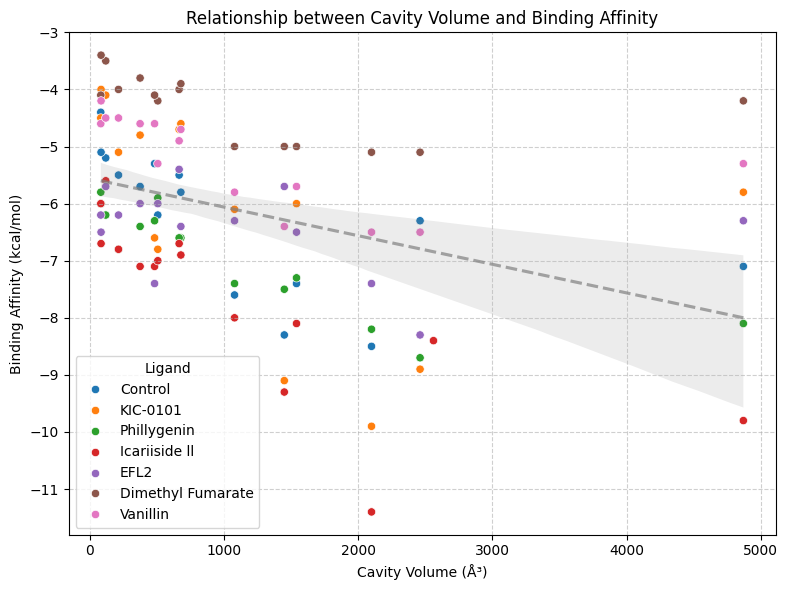

In [ ]:
# --- Scatter Plot: Binding affinity vs cavity volume ---
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Cavity Volume/Angstroms cubed',
    y='Binding Affinity',
    hue='Ligand',
    data=df,
    palette='tab10'
)
sns.regplot(
    x='Cavity Volume/Angstroms cubed',
    y='Binding Affinity',
    data=df,
    scatter=False,
    color='gray',
    line_kws={'linestyle':'--','alpha':0.7}
)

plt.title('Relationship between Cavity Volume and Binding Affinity')
plt.ylabel('Binding Affinity (kcal/mol)')
plt.xlabel('Cavity Volume (Å³)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr, spearmanr

# Calculate Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(
    df['Cavity Volume/Angstroms cubed'],
    df['Binding Affinity']
)

# Calculate Spearman correlation (monotonic relationship, non-parametric)
spearman_corr, spearman_p = spearmanr(
    df['Cavity Volume/Angstroms cubed'],
    df['Binding Affinity']
)

print(f"Pearson correlation: r = {pearson_corr:.3f}, p = {pearson_p:.3e}")
print(f"Spearman correlation: ρ = {spearman_corr:.3f}, p = {spearman_p:.3e}")

Pearson correlation: r = -0.403, p = 2.029e-05
Spearman correlation: ρ = -0.491, p = 1.063e-07


/tmp/ipython-input-2358703964.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_affinity.index, y=avg_affinity.values, palette='colorblind')


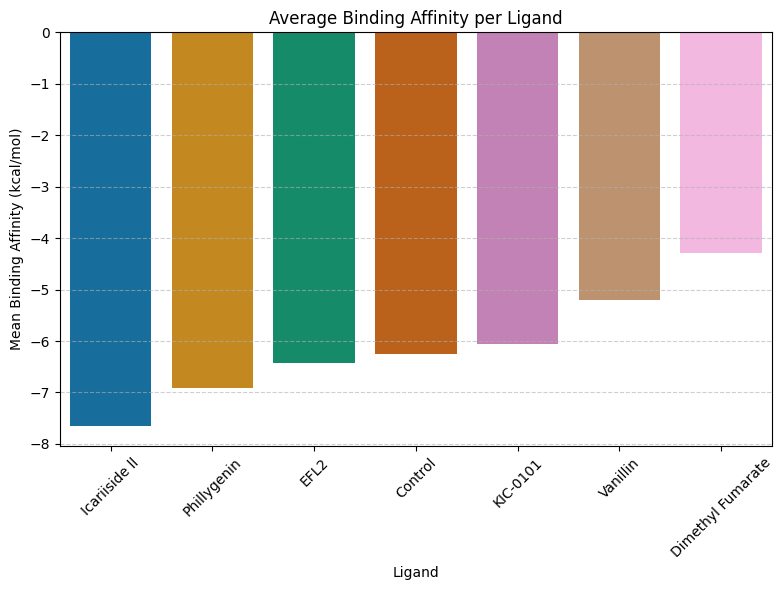

In [ ]:
# --- Bar Chart: Average binding affinity per ligand ---
avg_affinity = df.groupby('Ligand')['Binding Affinity'].mean().sort_values()
plt.figure(figsize=(8,6))
sns.barplot(x=avg_affinity.index, y=avg_affinity.values, palette='colorblind')
plt.title('Average Binding Affinity per Ligand')
plt.ylabel('Mean Binding Affinity (kcal/mol)')
plt.xlabel('Ligand')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1699692803.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Ligand', y='Binding Affinity', data=df_protein, palette='colorblind')


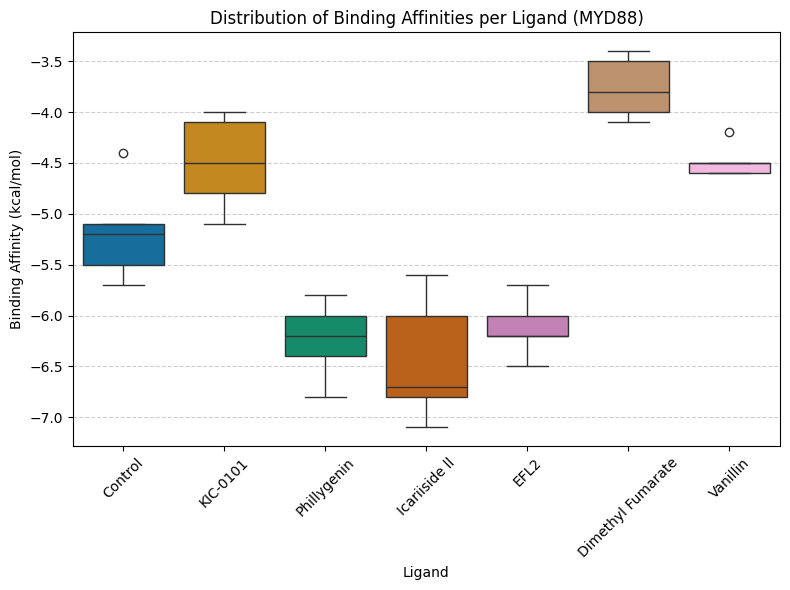

In [ ]:
# --- Select a specific protein to visualize ---
protein_to_plot = "MYD88"   # <-- Change this name to any protein (e.g., "IRAK1", "IRAK 4")

# Filter dataframe for only that protein
df_protein = df[df["Protein"] == protein_to_plot]

# --- Box Plot: Distribution of binding affinities per ligand for selected protein ---
plt.figure(figsize=(8,6))
sns.boxplot(x='Ligand', y='Binding Affinity', data=df_protein, palette='colorblind')
plt.title(f'Distribution of Binding Affinities per Ligand ({protein_to_plot})')
plt.ylabel('Binding Affinity (kcal/mol)')
plt.xlabel('Ligand')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


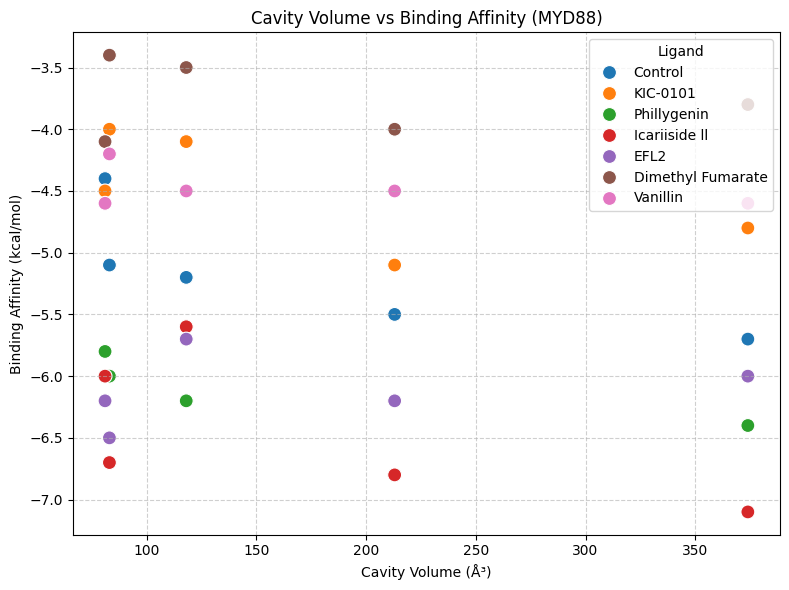

In [ ]:
# --- Scatter Plot: Cavity Volume vs Binding Affinity for selected protein ---
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Cavity Volume/Angstroms cubed',
    y='Binding Affinity',
    hue='Ligand',
    data=df_protein,
    palette='tab10',
    s=100
)
plt.title(f'Cavity Volume vs Binding Affinity ({protein_to_plot})')
plt.ylabel('Binding Affinity (kcal/mol)')
plt.xlabel('Cavity Volume (Å³)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1937674887.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_affinity.index, y=avg_affinity.values, palette='colorblind')


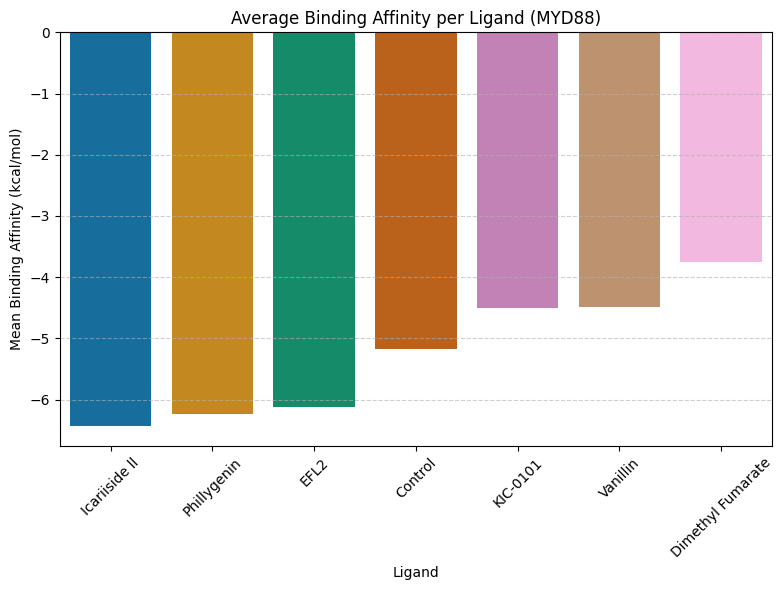

In [ ]:
# --- Bar Chart: Average Binding Affinity per Ligand for selected protein ---
avg_affinity = (
    df_protein.groupby('Ligand')['Binding Affinity']
    .mean()
    .sort_values()
)
plt.figure(figsize=(8,6))
sns.barplot(x=avg_affinity.index, y=avg_affinity.values, palette='colorblind')
plt.title(f'Average Binding Affinity per Ligand ({protein_to_plot})')
plt.ylabel('Mean Binding Affinity (kcal/mol)')
plt.xlabel('Ligand')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


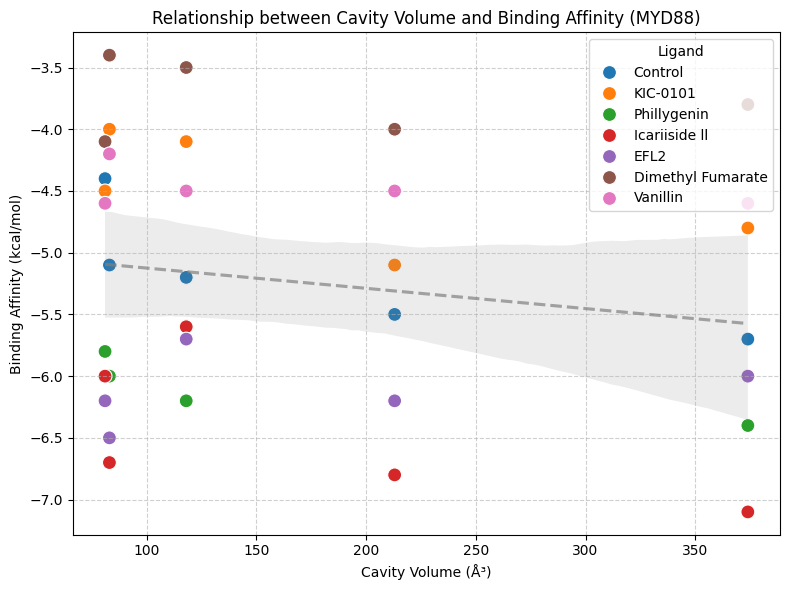

In [ ]:
# =====================
# 2. Scatter Plot (Binding Affinity vs. Cavity Volume)
# =====================
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Cavity Volume/Angstroms cubed',
    y='Binding Affinity',
    hue='Ligand',
    data=df_protein,
    palette='tab10',
    s=100
)
# Add trendline for visual correlation
sns.regplot(
    x='Cavity Volume/Angstroms cubed',
    y='Binding Affinity',
    data=df_protein,
    scatter=False,
    color='gray',
    line_kws={'linestyle':'--','alpha':0.7}
)
plt.title(f'Relationship between Cavity Volume and Binding Affinity ({protein_to_plot})')
plt.ylabel('Binding Affinity (kcal/mol)')
plt.xlabel('Cavity Volume (Å³)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Interpretation:
# - A downward trend: larger cavities → stronger binding (more negative affinity).
# - An upward trend: smaller cavities → stronger binding.


In [ ]:
from scipy.stats import pearsonr, spearmanr

# Calculate Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(
    df_protein['Cavity Volume/Angstroms cubed'],
    df_protein['Binding Affinity']
)

# Calculate Spearman correlation (monotonic relationship, non-parametric)
spearman_corr, spearman_p = spearmanr(
    df_protein['Cavity Volume/Angstroms cubed'],
    df_protein['Binding Affinity']
)

print(f"Pearson correlation: r = {pearson_corr:.3f}, p = {pearson_p:.3e}")
print(f"Spearman correlation: ρ = {spearman_corr:.3f}, p = {spearman_p:.3e}")


Pearson correlation: r = -0.140, p = 4.621e-01
Spearman correlation: ρ = -0.142, p = 4.546e-01


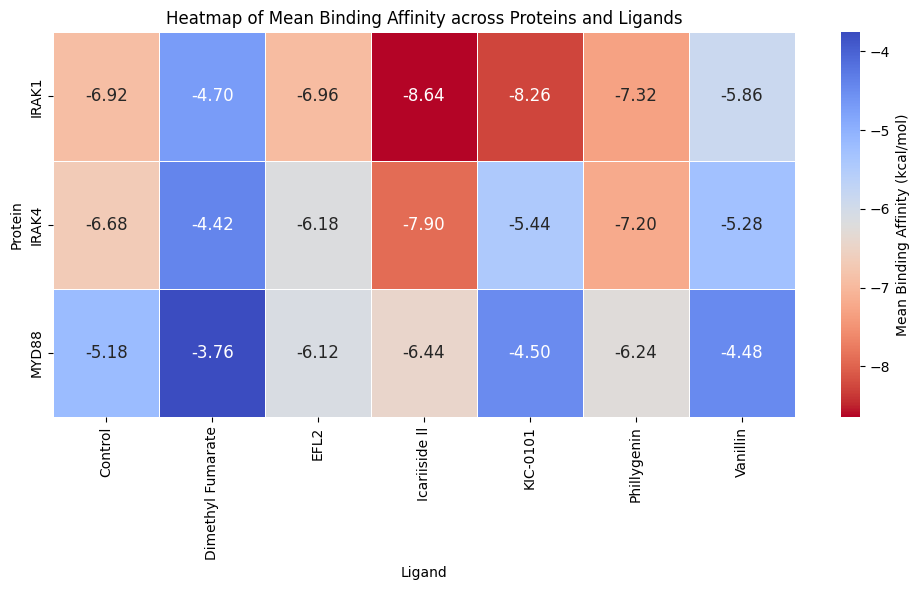

In [ ]:
# =====================
# 3. Heatmap (Across All Proteins and Ligands)
# =====================
# Compute mean binding affinity for each protein–ligand pair
heatmap_data = df.groupby(["Protein", "Ligand"])["Binding Affinity"].mean().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm_r",
    annot=True,
    annot_kws={"size": 12},
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Mean Binding Affinity (kcal/mol)"}
)
plt.title("Heatmap of Mean Binding Affinity across Proteins and Ligands")
plt.ylabel("Protein")
plt.xlabel("Ligand")
plt.tight_layout()
plt.show()

# Interpretation:
# - Darker (more negative) cells show stronger binding.
# - Each cell = average docking score for that protein–ligand pair.
# - Easy visual summary for publications or reports.

In [ ]:
avg_rmsd = df.groupby('Ligand')['RMSD'].mean().sort_values()
plt.figure(figsize=(8,6))
sns.barplot(x=avg_rmsd.index, y=avg_rmsd.values, palette='colorblind')
plt.title('Average RMSD per Ligand')
plt.ylabel('Mean RMSD (kcal/mol)')
plt.xlabel('Ligand')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.axhline(y=0.3, color='red', linestyle='--', linewidth=1.5, label='Acceptable Threshold (0.3)')
plt.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, label='Maximum Threshold (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'Ligand'